# Импорты, seed и среда

In [ ]:
%pip install datasets transformers torch scikit-learn matplotlib accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 1.5 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 828.1 kB/s  0:00:00m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 540.2 kB/s  0:00:06 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 315.9 kB/s  0:00:31 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 281.7 kB/s  0:00:10 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 556.1 kB/s  0:01:31m0:00:0100:02
  Attempting uninstall: regex
    Found existing installation: regex 2024.9.11
    Uninstalling regex-2024.9.11:
      Successfully uninstalled regex-2024.9.11
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.0
    Uninstalling pyarrow-19.0.0:
      Successfully uninstalled pyarrow-19.0.0━━━━━━━━━━━━━━━━━━━━━  3/11 [pyarrow]
  Attempting uninstall: dill━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/11 [pyarrow]
    Found existing installation: dill 0.3.8

In [6]:
%pip install --upgrade pyarrow accelerate

Note: you may need to restart the kernel to use updated packages.


In [1]:
import random
import numpy as np
import torch
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# Фиксируем seed
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


# Данные и первичный анализ

In [2]:
# Загружаем датасет emotion
dataset = load_dataset('emotion')

# Проверяем splits
print("Train size:", len(dataset['train']))
print("Validation size:", len(dataset['validation']))
print("Test size:", len(dataset['test']))

# Названия классов
labels = dataset['train'].features['label'].names
print("Labels:", labels)

# Примеры
for i in range(5):
    print(f"Example {i+1}:")
    print("Text:", dataset['train'][i]['text'])
    print("Label:", labels[dataset['train'][i]['label']])
    print()

print("Задача: классификация эмоций в тексте на основе предложений.")

Train size: 16000
Validation size: 2000
Test size: 2000
Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Example 1:
Text: i didnt feel humiliated
Label: sadness

Example 2:
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Label: sadness

Example 3:
Text: im grabbing a minute to post i feel greedy wrong
Label: anger

Example 4:
Text: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Label: love

Example 5:
Text: i am feeling grouchy
Label: anger

Задача: классификация эмоций в тексте на основе предложений.


# Токенизация

In [3]:
# Инициализируем токенизатор
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Примеры текстов
examples = [
    "I feel happy today!",
    "This is so frustrating.",
    "I'm really excited about this.",
    "I am sad and disappointed.",
    "What a wonderful surprise!"
]

for text in examples[:3]:  # Показываем на 3 примерах
    print(f"Text: {text}")
    tokens = tokenizer.tokenize(text)
    print(f"Tokens: {tokens}")
    encoded = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128)
    print(f"Input IDs: {encoded['input_ids'].tolist()}")
    print(f"Attention Mask: {encoded['attention_mask'].tolist()}")
    print(f"Special tokens: {tokenizer.special_tokens_map}")
    print()

# Пример padding и truncation
texts = ["Short text.", "This is a much longer text that should be truncated if max_length is set to a small value."]
encoded_batch = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=10)
print("Batch encoding with padding and truncation:")
print("Input IDs:", encoded_batch['input_ids'])
print("Attention Mask:", encoded_batch['attention_mask'])

Text: I feel happy today!
Tokens: ['i', 'feel', 'happy', 'today', '!']
Input IDs: [[101, 1045, 2514, 3407, 2651, 999, 102]]
Attention Mask: [[1, 1, 1, 1, 1, 1, 1]]
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}

Text: This is so frustrating.
Tokens: ['this', 'is', 'so', 'frustrating', '.']
Input IDs: [[101, 2023, 2003, 2061, 25198, 1012, 102]]
Attention Mask: [[1, 1, 1, 1, 1, 1, 1]]
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}

Text: I'm really excited about this.
Tokens: ['i', "'", 'm', 'really', 'excited', 'about', 'this', '.']
Input IDs: [[101, 1045, 1005, 1049, 2428, 7568, 2055, 2023, 1012, 102]]
Attention Mask: [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}

Batch encoding with padding and truncation:
Inp

# Инференс готовой модели

In [4]:
from transformers import pipeline

# Используем pipeline для sentiment analysis (готовую модель)
sentiment_pipeline = pipeline('sentiment-analysis', model='cardiffnlp/twitter-roberta-base-sentiment-latest')

# Примеры из датасета
test_texts = [dataset['test'][i]['text'] for i in range(5)]

for text in test_texts:
    result = sentiment_pipeline(text)
    print(f"Text: {text}")
    print(f"Prediction: {result}")
    print()

print("Готовая модель для sentiment подходит частично, так как датасет emotion имеет 6 классов, а эта модель бинарная или 3-классная. Для нашей задачи потребуется fine-tuning.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text: im feeling rather rotten so im not very ambitious right now
Prediction: [{'label': 'negative', 'score': 0.8814259171485901}]

Text: im updating my blog because i feel shitty
Prediction: [{'label': 'negative', 'score': 0.9240376949310303}]

Text: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Prediction: [{'label': 'negative', 'score': 0.6182978749275208}]

Text: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
Prediction: [{'label': 'positive', 'score': 0.9110472798347473}]

Text: i was feeling a little vain when i did this one
Prediction: [{'label': 'negative', 'score': 0.6724575757980347}]

Готовая модель для sentiment подходит частично, так как датасет emotion имеет 6 классов, а эта модель бинарная или 3-классная. Для нашей задачи потребуется fine-tuning.


# Fine-tuning для классификации текста

In [4]:
# Токенизируем датасет
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(['text'])
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch')

# Модель
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=6)
model.to(device)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    save_strategy='epoch',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir='./logs',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=lambda p: {
        'accuracy': accuracy_score(p.label_ids, p.predictions.argmax(-1)),
        'f1': f1_score(p.label_ids, p.predictions.argmax(-1), average='macro')
    }
)

# Обучение
trainer.train()

# Оценка на test
predictions = trainer.predict(tokenized_datasets['test'])
preds = predictions.predictions.argmax(-1)
labels_test = predictions.label_ids

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.205162,0.164107,0.930500,0.906153
2,0.111697,0.143947,0.938500,0.914087


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

# Оценка качества и краткий анализ ошибок

Accuracy: 0.9390
F1 Macro: 0.8989


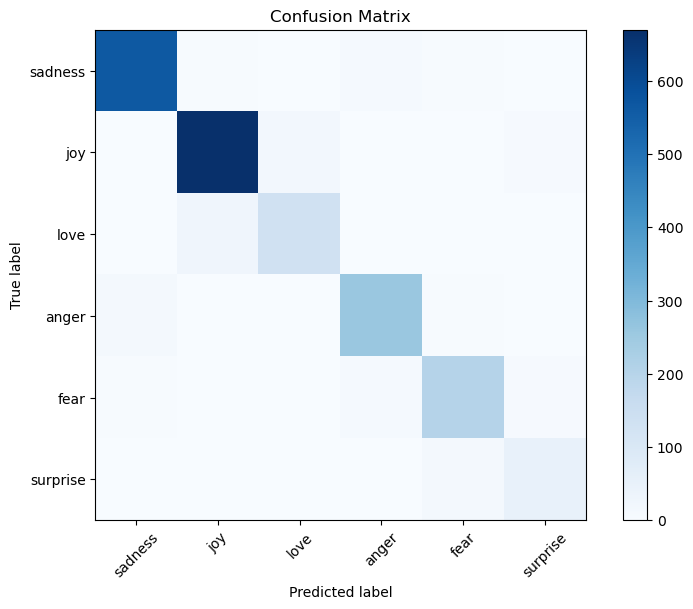

Sample predictions:
                                                text true_label pred_label  \
0  i feel so dirty but after spending a day at th...    sadness    sadness   
1  i could feel his breath on me and smell the sw...        joy       love   
2                   i just want to feel loved by you       love       love   
3  i have felt the need to write out my sometimes...      anger      anger   
4         at a party i met a girl who drew me to her      anger       fear   

   confidence  
0    0.999334  
1    0.874322  
2    0.997814  
3    0.970931  
4    0.460880  
Ошибки:
Text: i could feel his breath on me and smell the sweet scent of him
True: joy, Pred: love

Text: at a party i met a girl who drew me to her
True: anger, Pred: fear

Text: i feel this strange sort of liberation
True: surprise, Pred: fear



In [ ]:
# Метрики
acc = accuracy_score(labels_test, preds)
f1 = f1_score(labels_test, preds, average='macro')
print(f"Accuracy: {acc:.4f}")
print(f"F1 Macro: {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(labels_test, preds)
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=45)
plt.yticks(tick_marks, labels)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.savefig('artifacts/confusion_matrix.png')
plt.show()

# Sample predictions
sample_indices = np.random.choice(len(dataset['test']), 10, replace=False)
sample_df = pd.DataFrame({
    'text': [dataset['test'][i]['text'] for i in sample_indices],
    'true_label': [labels[dataset['test'][i]['label']] for i in sample_indices],
    'pred_label': [labels[preds[i]] for i in sample_indices],
    'confidence': [torch.softmax(torch.tensor(predictions.predictions[i]), dim=0).max().item() for i in sample_indices]
})
sample_df.to_csv('artifacts/sample_predictions.csv', index=False)

print("Sample predictions:")
print(sample_df.head())

# Анализ ошибок
errors = sample_df[sample_df['true_label'] != sample_df['pred_label']]
print("Ошибки:")
for _, row in errors.iterrows():
    print(f"Text: {row['text']}")
    print(f"True: {row['true_label']}, Pred: {row['pred_label']}")
    print()